<a href="https://colab.research.google.com/github/ritikarpawar/Tensorflow/blob/main/gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch: 0 D Loss: 0.28711426 G Loss: 0.4861238
Epoch: 500 D Loss: 5.833119 G Loss: 0.0017590057
Epoch: 1000 D Loss: 6.0580006 G Loss: 0.0008847239
Epoch: 1500 D Loss: 6.229345 G Loss: 0.00059161766
Epoch: 2000 D Loss: 6.3729687 G Loss: 0.0004445216
Epoch: 2500 D Loss: 6.49919 G Loss: 0.00035603915
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


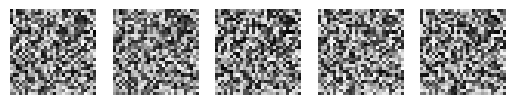

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape

# Load dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(-1, 28, 28, 1)

# Generator
generator = Sequential([
    Dense(128, activation='relu', input_shape=(100,)),
    Dense(784, activation='tanh'),
    Reshape((28, 28, 1))
])

# Discriminator
discriminator = Sequential([
    Flatten(input_shape=(28,28,1)),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

discriminator.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# GAN
discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(optimizer='adam',
            loss='binary_crossentropy')

# Training
epochs = 3000
batch_size = 64

for epoch in range(epochs):

    # Real images
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real = x_train[idx]

    # Fake images
    noise = np.random.normal(0,1,(batch_size,100))
    fake = generator.predict(noise, verbose=0)

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(real, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake, np.zeros((batch_size,1)))

    # Train generator
    noise = np.random.normal(0,1,(batch_size,100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    # Print losses
    if epoch % 500 == 0:
        print("Epoch:", epoch, "D Loss:", d_loss_real[0], "G Loss:", g_loss)

# Generate images
noise = np.random.normal(0,1,(5,100))
images = generator.predict(noise)

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i,:,:,0], cmap='gray')
    plt.axis('off')

plt.show()